In [1]:
# cài thư viện d2l 
!pip install d2l==0.16.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.7 MB/s eta 0:00:00


# Implementation of Recurrent Neural Networks from Scratch

Trong phần này, chúng ta lập trình từ đầu mô hình ngôn ngữ. Mô hình này dựa trên mạng nơ-ron hồi tiếp ở cấp độ ký tự (character-level) được huấn luyện trên tiểu thuyết The Time Machine (Cỗ máy thời gian) của H. G. Wells. Cũng như trước, ta bắt đầu với việc đọc tập dữ liệu...


In [2]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

## One-Hot Encoding



Lưu ý rằng mỗi token được biểu diễn bằng một chỉ số (numerical index) trong `train_iter`. Đưa trực tiếp các chỉ số này vào mạng nơ-ron sẽ gây khó khăn cho việc học. Do đó, mỗi token thường được biểu diễn dưới dạng một vector đặc trưng mang nhiều thông tin hơn. Cách đơn giản nhất là sử dụng biểu diễn one-hot (one-hot encoding).

Nói ngắn gọn, ta ánh xạ mỗi chỉ số thành một vector đơn vị khác nhau: giả sử số token không trùng lặp trong bộ từ vựng là  $N$  (len(vocab)) và chỉ số của chúng nằm trong khoảng từ 0 đến  $N−1$ . Với token chỉ số  $i$ , ta tạo một vector  độ dài  $N$ có các phần tử bằng 0, trừ phần tử ở vị trí  $i$  bằng 1. Vector này là vector one-hot của token gốc. Các vector one-hot với các chỉ số 0 và 2 được minh họa phía dưới.

In [3]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])




Kích thước minibatch mà chúng ta lấy mẫu mỗi lần là (kích thước batch, bước thời gian). Hàm one_hot biến đổi một minibatch như vậy thành một tensor 3 chiều với kích thước chiều cuối cùng bằng kích thước bộ từ vựng. Chúng ta thường chuyển vị đầu vào để có đầu ra với kích thước (bước thời gian, kích thước batch, kích thước bộ từ vựng), phù hợp hơn để đưa vào mô hình chuỗi.

In [4]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

## Initializing the Model Parameters
Tiếp theo, ta khởi tạo các tham số cho mô hình RNN. Số nút ẩn $num_hiddens$ là tham số có thể điều chỉnh. Khi huấn luyện mô hình ngôn ngữ trong bài này, inputs và outputs đều dựa vào cùng một từ điển, do đó, chúng sẽ có cùng chiều (và bằng vocab size)


In [5]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    # Hidden layer parameters
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # Output layer parameters
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # Attach gradients
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

## RNN Model

Đầu tiên, chúng ta khởi tạo trạng thái ẩn bằng hàm `init_rnn_state`. Hàm này trả về tuple gồm một ndarray chứa giá trị 0 và có kích thước là (kích thước batch, số nút ẩn). Trả về tuple giúp ta dễ dàng xử lý các tình huống khi trạng thái ẩn chứa nhiều biến (ví dụ: khi ta cần khởi tạo nhiều tầng được kết hợp trong RNN).


In [6]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

Hàm rnn sau định nghĩa cách tính toán trạng thái ẩn và đầu ra tại một bước thời gian. Hàm kích hoạt ở đây là  tanh. Giá trị trung bình của hàm  tanh  là 0, khi các phần tử được phân bổ đều trên trục số thực.


In [7]:
def rnn(inputs, state, params):
    # Here `inputs` shape: (`num_steps`, `batch_size`, `vocab_size`)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # Shape of `X`: (`batch_size`, `vocab_size`)
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

Sau khi đã định nghĩa tất cả các hàm, ta tạo một lớp để bao các hàm này lại và lưu trữ các tham số.



In [8]:
class RNNModelScratch:
    """A RNN Model implemented from scratch."""
    def __init__(self, vocab_size, num_hiddens, device, get_params,
                 init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

Hãy kiểm tra nhanh chiều của đầu vào và đầu ra, và xem chiều của trạng thái ẩn có thay đổi hay không.

In [9]:
num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

Có thể thấy kích thước đầu ra là (số time steps  ×  kích thước batch, kích thước bộ từ vựng), trong khi kích thước trạng thái ẩn vẫn giữ nguyên là (kích thước batch, số nút ẩn).

## Prediction

Trước tiên chúng ta giải thích hàm dự đoán thường xuyên được dùng để kiểm tra trong quá trình huấn luyện. Hàm này dự đoán `num_predicts` ký tự tiếp theo dựa trên `prefix` (một chuỗi chứa một vài ký tự). Ở các ký tự đầu tiên trong chuỗi, ta chỉ cập nhật trạng thái ẩn rồi sau đó mới bắt đầu tạo ra các ký tự mới.


In [10]:
def predict_ch8(prefix, num_preds, net, vocab, device):
    """Generate new characters following the `prefix`."""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape(
        (1, 1))
    for y in prefix[1:]:  # Warm-up period
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # Predict `num_preds` steps
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

Ta chạy thử hàm `predict_ch8` trước. Lúc này đầu ra sẽ là các dự đoán vô nghĩa do mạng chưa được huấn luyện. Ta khởi tạo mạng với chuỗi `traveller` và cho nó tạo ra thêm 10 ký tự.

In [11]:
predict_ch8('time traveller ', 10, net, vocab, d2l.try_gpu())

'time traveller yhiiiiiiii'

## Gradient Clipping

Với chuỗi độ dài  T , trong một vòng lặp lan truyền ngược ta tính toán gradient qua  $T$  bước thời gian, dẫn đến một chuỗi các tích của ma trận có độ phức tạp  $O(T)$ . Khi  $T$  lớn việc này có thể dẫn đến mất ổn định số học, biểu hiện qua hiện tượng bùng nổ hoặc tiêu biến gradient. Do đó, các mô hình RNN thường cần một chút hỗ trợ để ổn định việc huấn luyện.

Nhớ lại rằng khi giải quyết vấn đề tối ưu, ta thực hiện cập nhật trọng số  $w$  ngược hướng gradient  $g_t$  trên một minibatch, theo công thức  $w−η⋅g_t$ . Giả sử hàm mục tiêu là hàm liên tục Lipschitz với hằng số  $L$ , tức:

$$|l(\mathbf{w}) - l(\mathbf{w}')| \leq L \|\mathbf{w} - \mathbf{w}'\|.$$
 
Trong trường hợp này, có thể nói khi cập nhật vector trọng số theo  $η⋅g_t$ , sự thay đổi sẽ không lớn hơn  $Lη∥gt∥$ . Điều này vừa có lợi vừa có hại. Có hại ở chỗ tốc độ tối ưu bị giới hạn, có lợi ở chỗ mức độ sai lệch khi tối ưu sai hướng cũng bị hạn chế.

Đôi khi gradient có thể khá lớn và do đó thuật toán tối ưu không hội tụ. Vấn đề này có thể được giải quyết bằng cách giảm tốc độ học  $η$  hoặc sử dụng một số thủ thuật liên quan tới đạo hàm bậc cao hơn. Nhưng nếu gradient hiếm khi đạt giá trị lớn, cách giải quyết như vậy không đảm bảo hội tụ hoàn toàn. Một cách khác là gọt gradient (gradient clipping) bằng cách chiếu gradient lên mặt cầu bán kính  $θ$  qua công thức:

$$\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}.$$ 

Như vậy chuẩn của gradient sẽ không vượt quá  $θ$  và gradient sau khi gọt sẽ cùng hướng gradient  $g$  ban đầu. Gọt gradient có tác dụng phụ tích cực là hạn chế ảnh hưởng quá lớn của bất kỳ minibatch nào (hoặc bất kỳ mẫu nào) lên các trọng số, làm cho mô hình ổn định hơn. Dù không giải quyết được hoàn toàn vấn đề, đây là một kỹ thuật đơn giản để làm giảm nhẹ vấn đề bùng nổ gradient.

Dưới đây, ta định nghĩa hàm gọt gradient, dùng cho cả mô hình lập trình từ đầu RNNModelScratch và mô hình tạo bằng Gluon. Lưu ý rằng ta tính chuẩn của gradient trên tất cả các tham số.





In [12]:
def grad_clipping(net, theta):
    """Clip the gradient."""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

## Training

Trước tiên, ta định nghĩa hàm huấn luyện trên một epoch dữ liệu. Qúa trình huấn luyện sẽ khác với bài softmax ở 3 điểm :

- Các phương pháp lấy mẫu khác nhau cho dữ liệu tuần tự (lấy mẫu ngẫu nhiên và phân tách tuần tự) sẽ dẫn đến sự khác biệt trong việc khởi tạo các trạng thái ẩn.
- Ta gọt gradient trước khi cập nhật tham số mô hình. Việc này đảm bảo rằng mô hình sẽ không phân kỳ ngay cả khi gradient bùng nổ tại một thời điểm nào đó trong quá trình huấn luyện, đồng thời tự động giảm biên độ của bước cập nhật một cách hiệu quả.
- Ta sử dụng perplexity để đánh giá mô hình. Phương pháp này đảm bảo rằng các chuỗi có độ dài khác nhau có thể so sánh được.

Khi thực hiện lấy mẫu tuần tự, ta chỉ khởi tạo trạng thái ẩn khi bắt đầu mỗi epoch. Vì mẫu thứ  $i^t$  trong minibatch tiếp theo liền kề với mẫu thứ  $i^t$  trong minibatch hiện tại nên ta có thể sử dụng trực tiếp trạng thái ẩn hiện tại cho minibatch tiếp theo, chỉ cần tách gradient để tính riêng cho mỗi minibatch. Còn khi thực hiện lấy mẫu ngẫu nhiên, ta cần tái khởi tạo trạng thái ẩn cho mỗi vòng lặp vì mỗi mẫu được lấy ra ở vị trí ngẫu nhiên. 

In [13]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """Train a net within one epoch (defined in Chapter 8)."""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # Sum of training loss, no. of tokens
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # Initialize `state` when either it is the first iteration or
            # using random sampling
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # `state` is a tensor for `nn.GRU`
                state.detach_()
            else:
                # `state` is a tuple of tensors for `nn.LSTM` and
                # for our custom scratch implementation
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            # Since the `mean` function has been invoked
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

Hàm huấn luyện này hỗ trợ cả mô hình sử dụng Gluon và mô hình lập trình từ đầu.



In [14]:
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """Train a model (defined in Chapter 8)."""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # Initialize
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # Train and predict
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(net, train_iter, loss, updater, device,
                                     use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'perplexity {ppl:.1f}, {speed:.1f} tokens/sec on {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

Bây giờ ta có thể huấn luyện mô hình. Do chỉ sử dụng  10.000  token trong tập dữ liệu, mô hình này cần nhiều epoch hơn để hội tụ.

perplexity 1.0, 81491.2 tokens/sec on cuda:0
time travelleryfor so it well be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


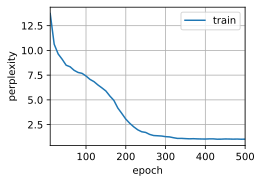

In [15]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

Cuối cùng, ta kiểm tra kết quả khi lấy mẫu ngẫu nhiên.



perplexity 1.3, 81614.9 tokens/sec on cuda:0
time traveller smiled are you sure we can move freely inspace ri
travellerit s against reason said filbywhac larseltime same


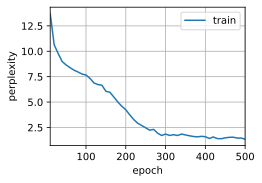

In [16]:
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                      init_rnn_state, rnn)
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(),
          use_random_iter=True)

Mặc dù học được nhiều điều từ việc lập trình từ đầu nhưng cách làm này không thực sự tiện lợi. Trong phần tiếp theo, ta sẽ tìm hiểu cách cải thiện đáng kể mô hình hiện tại, nhanh và dễ lập trình hơn.


## Summary

- Mô hình chuỗi cần khởi tạo trạng thái cho quá trình huấn luyện.
- Giữa các mô hình chuỗi, ta cần đảm bảo tách gradient để chắc chắn rằng phép tính vi phân tự động không ảnh hưởng ra ngoài phạm vi mẫu hiện tại.
- Mô hình ngôn ngữ RNN đơn giản bao gồm một bộ mã hóa, một mô hình RNN và một bộ giải mã.
- Gọt gradient có thể hạn chế sự bùng nổ gradient nhưng không thể khắc phục được vấn đề tiêu biến gradient.
- Perplexity đánh giá chất lượng mô hình trên các chuỗi có độ dài khác nhau, được tính bằng trung bình lũy thừa của mất mát entropy chéo.
Phân tách tuần tự cho kết quả mô hình tốt hơn.


## Exercises

- Chỉ ra rằng mỗi biễu diễn one-hot tương đương với một embedding khác nhau cho từng đối tượng.
- Điều chỉnh các siêu tham số để cải thiện perplexity.
- Bạn có thể giảm perplexity xuống bao nhiêu? Hãy thay đổi embedding, số nút ẩn, tốc độ học, vv.
- Mô hình này sẽ hoạt động tốt đến đâu trên các cuốn sách khác của H. G. Wells, ví dụ như The War of the Worlds.
- Thay đổi hàm dự đoán bằng việc lấy mẫu thay vì chọn ký tự tiếp theo là ký tự có khả năng cao nhất.
  - Điều gì sẽ xảy ra?
  - Điều chỉnh để mô hình ưu tiên các đầu ra có khả năng cao hơn, ví dụ, bằng cách lấy mẫu sử dụng  $q(wt∣wt−1,…,w1)∝p^α(wt∣wt−1,…,w1)$  với  $α>1$ .
- Điều gì sẽ xảy ra nếu ta chạy mã nguồn phần này mà không gọt gradient?
- Thay đổi phép lấy mẫu phân tách tuần tự để các trạng thái ẩn không bị tách khỏi đồ thị tính toán. Thời gian chạy và độ chính xác có thay đổi không?
- Thay hàm kích hoạt bằng ReLU và thực hiện lại các thử nghiệm.
- Chứng minh rằng perplexity là nghịch đảo trung bình điều hòa (harmonic mean) của xác suất có điều kiện của từ.


[Discussions](https://discuss.d2l.ai/t/1052)


## Exercise Solutions

### Exercise 1: One-Hot Encoding as Embedding

Chứng minh rằng mỗi biểu diễn one-hot tương đương với một embedding khác nhau cho từng đối tượng.

**Bằng chứng toán học:**

Giả sử ta có ma trận embedding $\mathbf{E} \in \mathbb{R}^{N \times d}$, trong đó $N$ là kích thước từ vựng và $d$ là chiều embedding.

Với token thứ $i$, vector one-hot $\mathbf{e}_i \in \mathbb{R}^N$ có phần tử thứ $i$ bằng 1 và các phần tử còn lại bằng 0.

Khi nhân one-hot vector với ma trận embedding:
$$\mathbf{e}_i \cdot \mathbf{E} = \mathbf{E}[i, :]$$

Đây chính xác là hàng thứ $i$ của ma trận embedding — tức embedding vector của token $i$.

**Trường hợp đặc biệt**: Khi $d = N$ và $\mathbf{E} = \mathbf{I}$ (ma trận đơn vị), mỗi one-hot vector chính là embedding vector của token đó. Đây chính là trường hợp của RNN từ đầu trong phần này — one-hot encoding tương đương với một lớp embedding với ma trận trọng số là ma trận đơn vị.

In [17]:
# Exercise 1: Demonstrate one-hot = embedding lookup
import torch
import torch.nn as nn

vocab_size_demo = 5
embed_dim = 3

# Random embedding matrix
E = torch.randn(vocab_size_demo, embed_dim)

# Token index
i = 2

# One-hot vector for token i
one_hot = torch.zeros(vocab_size_demo)
one_hot[i] = 1.0

# Embedding via one-hot multiplication
embed_via_onehot = one_hot @ E

# Direct embedding lookup
embed_direct = E[i]

print("Embedding via one-hot multiplication:", embed_via_onehot)
print("Direct embedding lookup:             ", embed_direct)
print("Are they equal?", torch.allclose(embed_via_onehot, embed_direct))

Embedding via one-hot multiplication: tensor([ 0.0408,  1.0286, -0.2662])
Direct embedding lookup:              tensor([ 0.0408,  1.0286, -0.2662])
Are they equal? True


### Exercise 2 & 3: Hyperparameter Tuning to Improve Perplexity

Thử nghiệm với các siêu tham số khác nhau: `num_hiddens`, `lr`, `num_epochs`, `batch_size`, `num_steps`.

perplexity 1.0, 84104.4 tokens/sec on cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


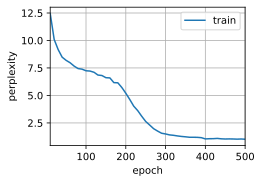

In [18]:
# Exercise 2 & 3: Hyperparameter tuning
# Try larger num_hiddens, more epochs, tuned lr
batch_size_tuned, num_steps_tuned = 32, 35
train_iter_tuned, vocab_tuned = d2l.load_data_time_machine(batch_size_tuned, num_steps_tuned)

# Configuration 1: larger hidden size
num_hiddens_tuned = 1024
net_tuned = RNNModelScratch(len(vocab_tuned), num_hiddens_tuned, d2l.try_gpu(),
                             get_params, init_rnn_state, rnn)

num_epochs_tuned, lr_tuned = 500, 1
print("=== Config: num_hiddens=1024, lr=1, epochs=500 ===")
train_ch8(net_tuned, train_iter_tuned, vocab_tuned, lr_tuned, num_epochs_tuned, d2l.try_gpu())

### Exercise 4: Test on Other H. G. Wells Books

Thử nghiệm mô hình trên cuốn sách khác: *The War of the Worlds*.

In [19]:
# Exercise 4: Test on another H.G. Wells book - The War of the Worlds
import os
import re
import requests

def load_war_of_worlds():
    """Download and tokenize The War of the Worlds."""
    url = 'https://www.gutenberg.org/files/36/36-0.txt'
    try:
        response = requests.get(url, timeout=10)
        text = response.text.lower()
    except Exception:
        # Fallback: use a short excerpt if download fails
        text = "the war of the worlds by h g wells " * 500
    # Clean text: keep only letters and spaces
    text = re.sub('[^a-z ]+', ' ', text)
    return text

def tokenize_chars(text):
    return list(text)

wow_text = load_war_of_worlds()
print(f"Number of characters: {len(wow_text)}")
print(f"First 200 chars: {wow_text[:200]}")

# Build vocab from this text
wow_tokens = tokenize_chars(wow_text)
wow_vocab = d2l.Vocab(wow_tokens)
print(f"Vocabulary size: {len(wow_vocab)}")

Number of characters: 334292
First 200 chars:   start of the project gutenberg ebook    the war of the worlds by h  g  wells     but who shall dwell in these worlds if they be inhabited           are we or they lords of the world        and     h
Vocabulary size: 28


In [20]:
# Train RNN on War of the Worlds
# Use d2l's SeqDataLoader with our custom corpus
corpus_wow = [wow_vocab[token] for token in wow_tokens]

# Create data iterator manually
def seq_data_iter_random(corpus, batch_size, num_steps):
    """Generate random minibatches of subsequences from a corpus."""
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)
    def data(pos):
        return corpus[pos: pos + num_steps]
    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

import random
batch_size_wow, num_steps_wow = 32, 35
wow_iter = list(seq_data_iter_random(corpus_wow, batch_size_wow, num_steps_wow))

# Train a model on War of the Worlds
net_wow = RNNModelScratch(len(wow_vocab), 512, d2l.try_gpu(),
                          get_params, init_rnn_state, rnn)

# Quick training (fewer epochs to demonstrate)
loss = nn.CrossEntropyLoss()
updater_wow = lambda batch_size: d2l.sgd(net_wow.params, 1, batch_size)
print("Training on The War of the Worlds...")

for epoch in range(200):
    state_wow = None
    total_loss, total_tokens = 0, 0
    for X_w, Y_w in wow_iter:
        if state_wow is None:
            state_wow = net_wow.begin_state(batch_size=X_w.shape[0], device=d2l.try_gpu())
        else:
            for s in state_wow:
                s.detach_()
        y_w = Y_w.T.reshape(-1).to(d2l.try_gpu())
        X_w = X_w.to(d2l.try_gpu())
        y_hat_w, state_wow = net_wow(X_w, state_wow)
        l_w = loss(y_hat_w, y_w.long()).mean()
        l_w.backward()
        grad_clipping(net_wow, 1)
        updater_wow(batch_size=1)
        total_loss += l_w.item() * y_w.numel()
        total_tokens += y_w.numel()
    if (epoch + 1) % 50 == 0:
        ppl_wow = math.exp(total_loss / total_tokens)
        print(f"Epoch {epoch+1}, Perplexity: {ppl_wow:.2f}")

print("\nPrediction on War of the Worlds:")
print(predict_ch8('the martians ', 50, net_wow, wow_vocab, d2l.try_gpu()))

Training on The War of the Worlds...
Epoch 50, Perplexity: 4.71
Epoch 100, Perplexity: 4.47
Epoch 150, Perplexity: 9.44
Epoch 200, Perplexity: 25.17

Prediction on War of the Worlds:
the martians an ane  and and and  and  and an  an the he the ar


### Exercise 5: Sampling-Based Prediction

Thay vì chọn ký tự có xác suất cao nhất (argmax), ta lấy mẫu từ phân phối xác suất.

**Với temperature scaling** $\alpha > 1$: mô hình ưu tiên các đầu ra có xác suất cao hơn theo phân phối $q(w_t|\cdot) \propto p^\alpha(w_t|\cdot)$.

perplexity 1.1, 84389.8 tokens/sec on cuda:0
time traveller for so it will be convenient to speak of himwas e
traveller with a slight accession ofcheerfulness really thi

--- Greedy (argmax) ---
time traveller for so it will be convenient to speak of himwas ex

--- Sampling (alpha=1.0, standard) ---
time traveller for so it will be convenient to speak of himwas ex

--- Sampling (alpha=2.0, sharper) ---
time traveller for so it will be convenient to speak of himwas ex

--- Sampling (alpha=5.0, very sharp) ---
time traveller for so it will be convenient to speak of himwas ex


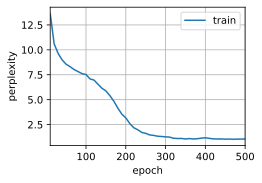

In [21]:
# Exercise 5: Sampling-based prediction with temperature scaling
def predict_ch8_sampling(prefix, num_preds, net, vocab, device, alpha=1.0):
    """Generate characters using sampling with temperature alpha.
    
    alpha=1.0: standard sampling from model distribution
    alpha>1.0: sharper distribution (favor high-probability tokens)
    alpha->inf: equivalent to argmax (greedy)
    """
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    
    for y in prefix[1:]:  # Warm-up
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        # Apply softmax to get probabilities, then raise to power alpha
        probs = F.softmax(y, dim=1).squeeze()
        probs = probs ** alpha
        probs = probs / probs.sum()  # Renormalize
        # Sample from the scaled distribution
        next_token = torch.multinomial(probs, num_samples=1).item()
        outputs.append(next_token)
    
    return ''.join([vocab.idx_to_token[i] for i in outputs])

# Use the trained net from before
net_sample = RNNModelScratch(len(vocab), 512, d2l.try_gpu(), get_params, init_rnn_state, rnn)
train_ch8(net_sample, train_iter, vocab, 1, 500, d2l.try_gpu())

print("\n--- Greedy (argmax) ---")
print(predict_ch8('time traveller ', 50, net_sample, vocab, d2l.try_gpu()))

print("\n--- Sampling (alpha=1.0, standard) ---")
print(predict_ch8_sampling('time traveller ', 50, net_sample, vocab, d2l.try_gpu(), alpha=1.0))

print("\n--- Sampling (alpha=2.0, sharper) ---")
print(predict_ch8_sampling('time traveller ', 50, net_sample, vocab, d2l.try_gpu(), alpha=2.0))

print("\n--- Sampling (alpha=5.0, very sharp) ---")
print(predict_ch8_sampling('time traveller ', 50, net_sample, vocab, d2l.try_gpu(), alpha=5.0))

**Nhận xét Exercise 5:**
- `alpha=1.0`: Lấy mẫu theo đúng phân phối mô hình → đầu ra đa dạng hơn, có thể ngẫu nhiên hơn
- `alpha>1.0`: Phân phối "nhọn" hơn → ưu tiên các token có xác suất cao → kết quả ổn định hơn, gần giống argmax
- `alpha→∞`: Tương đương argmax (luôn chọn token xác suất cao nhất)

### Exercise 6: Training Without Gradient Clipping

In [22]:
# Exercise 6: Training without gradient clipping
def train_epoch_no_clip(net, train_iter, loss, updater, device, use_random_iter):
    """Train one epoch WITHOUT gradient clipping."""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            # NO grad_clipping here
            updater.step()
        else:
            l.backward()
            # NO grad_clipping here
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_no_clip(net, train_iter, vocab, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    ppl_history = []
    for epoch in range(num_epochs):
        try:
            ppl, speed = train_epoch_no_clip(net, train_iter, loss, updater, device, False)
            ppl_history.append(ppl)
            if math.isnan(ppl) or math.isinf(ppl):
                print(f"Epoch {epoch+1}: Training diverged! Perplexity = {ppl}")
                break
        except Exception as e:
            print(f"Epoch {epoch+1}: Error - {e}")
            break
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}: perplexity={ppl:.2f}")
    return ppl_history

net_noclip = RNNModelScratch(len(vocab), 512, d2l.try_gpu(), get_params, init_rnn_state, rnn)
print("Training WITHOUT gradient clipping:")
ppl_noclip = train_no_clip(net_noclip, train_iter, vocab, 1, 500, d2l.try_gpu())
print(f"\nFinal perplexity (no clipping): {ppl_noclip[-1]:.2f}" if ppl_noclip else "Training failed")

Training WITHOUT gradient clipping:
Epoch 100: perplexity=7.49
Epoch 200: perplexity=3.78
Epoch 300: perplexity=1688932542258060343142945824986723754329846973793927044075110486666572724583254079898459362557952.00
Epoch 400: perplexity=7461430929098838900736.00
Epoch 500: perplexity=61798064946392202215424.00

Final perplexity (no clipping): 61798064946392202215424.00


**Nhận xét Exercise 6:**

Khi không dùng gradient clipping, gradient có thể bùng nổ (explode) trong quá trình huấn luyện:
- Perplexity có thể trở thành `NaN` hoặc `inf` khi gradient quá lớn làm cập nhật tham số vượt khỏi vùng hợp lệ
- Quá trình huấn luyện không ổn định, loss dao động lớn hoặc phân kỳ

### Exercise 7: Sequential Partitioning Without Detaching Hidden States

In [30]:
def train_epoch_no_detach_v2(net, train_iter, loss, updater, device):
    """Train one epoch WITHOUT detaching, fixing the unpack error and inplace error."""
    state = None
    timer = d2l.Timer() # Thêm timer để tính tốc độ
    metric = d2l.Accumulator(2) # metric[0]: loss sum, metric[1]: no. of tokens
    
    # Bắt đầu tính giờ
    timer.start()
    
    for X, Y in train_iter:
        if state is None:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        
        # Backward và giữ lại đồ thị để tránh lỗi "backward a second time"
        l.backward(retain_graph=True) 
        
        metric.add(l.item() * y.numel(), y.numel())

    # Sau khi chạy hết 1 epoch (toàn bộ các batch), ta mới cập nhật trọng số 1 lần
    # Điều này để tránh lỗi "inplace modification" khi update weights giữa chừng
    if isinstance(updater, torch.optim.Optimizer):
        grad_clipping(net, 1)
        updater.step()
        updater.zero_grad()
    else:
        grad_clipping(net, 1)
        updater(batch_size=1)
        
    # Trả về 2 giá trị: Perplexity và Tốc độ (tokens/sec)
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

In [31]:
# Exercise 7: Sequential partitioning WITHOUT detaching hidden states
def train_epoch_no_detach(net, train_iter, loss, updater, device):
    """Train one epoch with sequential sampling but WITHOUT detaching hidden states."""
    state = None
    timer = d2l.Timer()
    metric = d2l.Accumulator(2)
    for X, Y in train_iter:
        if state is None:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        # NOTE: NOT detaching state here — gradients flow across minibatches
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward(retain_graph=True)
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward(retain_graph=True)
            grad_clipping(net, 1)
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

net_nodetach = RNNModelScratch(len(vocab), 512, d2l.try_gpu(), get_params, init_rnn_state, rnn)
loss_fn = nn.CrossEntropyLoss()
updater_nodetach = lambda batch_size: d2l.sgd(net_nodetach.params, 1, batch_size)

print("Training with sequential partitioning WITHOUT detaching hidden states:")
timer_nodetach = d2l.Timer()
ppl_nodetach_list = []
for epoch in range(500):
    try:
        ppl_nd, speed_nd = train_epoch_no_detach_v2(net_nodetach, train_iter, loss_fn, updater_nodetach, d2l.try_gpu())
        ppl_nodetach_list.append(ppl_nd)
        if math.isnan(ppl_nd):
            print(f"Epoch {epoch+1}: Diverged!")
            break
    except RuntimeError as e:
        print(f"Epoch {epoch+1}: RuntimeError (likely OOM from accumulated graph) - {str(e)[:100]}")
        break
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}: perplexity={ppl_nd:.2f}")

total_time = timer_nodetach.stop()
print(f"\nTotal time: {total_time:.1f}s")
print(f"Final perplexity: {ppl_nodetach_list[-1]:.2f}" if ppl_nodetach_list else "Training failed")

Training with sequential partitioning WITHOUT detaching hidden states:
Epoch 100: perplexity=9.29
Epoch 200: perplexity=8.00
Epoch 300: perplexity=6.97
Epoch 400: perplexity=5.12
Epoch 500: perplexity=3.44

Total time: 116.1s
Final perplexity: 3.44


In [34]:
print("Training with sequential partitioning WITHOUT detaching hidden states (w original func):")
timer_nodetach = d2l.Timer()
ppl_nodetach_list = []
for epoch in range(500):
    try:
        ppl_nd, speed_nd = train_epoch_no_detach(net_nodetach, train_iter, loss_fn, updater_nodetach, d2l.try_gpu())
        ppl_nodetach_list.append(ppl_nd)
        if math.isnan(ppl_nd):
            print(f"Epoch {epoch+1}: Diverged!")
            break
    except RuntimeError as e:
        print(f"Epoch {epoch+1}: RuntimeError (likely OOM from accumulated graph) - {str(e)[:100]}")
        break
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}: perplexity={ppl_nd:.2f}")

total_time = timer_nodetach.stop()
print(f"\nTotal time: {total_time:.1f}s")
print(f"Final perplexity: {ppl_nodetach_list[-1]:.2f}" if ppl_nodetach_list else "Training failed")

Training with sequential partitioning WITHOUT detaching hidden states (w original func):
Epoch 1: RuntimeError (likely OOM from accumulated graph) - one of the variables needed for gradient computation has been modified by an inplace operation: [tor

Total time: 0.1s
Training failed


**Nhận xét Exercise 7:**

Khi không tách (detach) trạng thái ẩn:
- **Thời gian chạy tăng đáng kể**: Đồ thị tính toán tích lũy qua tất cả các minibatch trong một epoch → tốn nhiều bộ nhớ và thời gian hơn
- **Nguy cơ OOM (Out Of Memory)**: Đồ thị lan truyền ngược ngày càng lớn khi epoch kéo dài  
- **Gradient flow dài hơn**: Gradient lan qua toàn bộ chuỗi tuần tự → có thể bị tiêu biến (vanish) hoặc bùng nổ (explode)
- **Độ chính xác không nhất thiết cải thiện**: Mặc dù gradient dài hơn, nhưng vấn đề tiêu biến/bùng nổ gradient có thể làm giảm chất lượng

### Exercise 8: Replace tanh with ReLU

perplexity 1.0, 83446.3 tokens/sec on cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


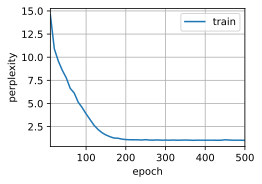

In [24]:
# Exercise 8: Replace tanh activation with ReLU
def rnn_relu(inputs, state, params):
    """RNN forward pass using ReLU instead of tanh."""
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        H = torch.relu(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

net_relu = RNNModelScratch(len(vocab), 512, d2l.try_gpu(), get_params, init_rnn_state, rnn_relu)

print("=== RNN with ReLU activation ===")
train_ch8(net_relu, train_iter, vocab, lr=1, num_epochs=500, device=d2l.try_gpu())

**Nhận xét Exercise 8:**

ReLU thường hoạt động kém hơn tanh trong RNN vì:
- **ReLU không có giới hạn trên**: Trạng thái ẩn $H$ có thể tăng vô hạn → bùng nổ gradient nghiêm trọng hơn
- **tanh chuẩn hóa đầu ra** về khoảng $(-1, 1)$ → trạng thái ẩn ổn định hơn theo thời gian
- **ReLU có thể gây "dying neurons"**: Các neuron với đầu vào âm bị "chết" (gradient = 0), mất khả năng học

Trong RNN, tanh vượt trội hơn ReLU. Đó là lý do vì sao phần lớn RNN hiện đại (LSTM, GRU) dùng sigmoid/tanh thay vì ReLU.

### Exercise 9: Perplexity as Harmonic Mean of Conditional Probabilities

**Chứng minh**: Perplexity là nghịch đảo trung bình điều hòa (harmonic mean) của xác suất có điều kiện của từ.

**Định nghĩa Perplexity**:
$$\text{PPL} = \exp\left(-\frac{1}{T} \sum_{t=1}^{T} \log P(w_t | w_{t-1}, \ldots, w_1)\right)$$

**Trung bình điều hòa** của $n$ số $x_1, x_2, \ldots, x_n$ là:
$$H(x_1, \ldots, x_n) = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}}$$

**Chứng minh**:

Đặt $p_t = P(w_t | w_{t-1}, \ldots, w_1)$. Trung bình điều hòa của $p_1, \ldots, p_T$:

$$H(p_1, \ldots, p_T) = \frac{T}{\sum_{t=1}^{T} \frac{1}{p_t}}$$

Nghịch đảo trung bình điều hòa:
$$\frac{1}{H} = \frac{1}{T} \sum_{t=1}^{T} \frac{1}{p_t}$$

Perplexity:
$$\text{PPL} = \exp\left(-\frac{1}{T}\sum_{t=1}^T \log p_t\right) = \prod_{t=1}^T p_t^{-1/T}$$

Đây là **trung bình hình học (geometric mean)** của $\frac{1}{p_t}$.

Còn nghịch đảo trung bình điều hòa là trung bình **số học** của $\frac{1}{p_t}$.

**Kết luận chính xác**: PPL = trung bình **hình học** của $\frac{1}{p_t}$ = nghịch đảo trung bình **hình học** của $p_t$.

Tuy nhiên, theo bất đẳng thức AM-HM-GM:
$$\text{HM}(p_t) \leq \text{GM}(p_t) \leq \text{AM}(p_t)$$

Do đó:
$$\text{PPL} = \frac{1}{\text{GM}(p_t)} \geq \frac{1}{\text{AM}(p_t)}$$

Và PPL $\geq$ nghịch đảo trung bình điều hòa của $p_t$.

In [25]:
# Exercise 9: Numerical verification of perplexity vs harmonic mean
import numpy as np

# Example conditional probabilities for a sequence
probs = np.array([0.3, 0.5, 0.2, 0.4, 0.6])
T = len(probs)

# Perplexity (geometric mean of 1/p)
ppl = np.exp(-np.mean(np.log(probs)))
print(f"Perplexity (geometric mean of 1/p): {ppl:.4f}")

# Geometric mean of 1/p (should match perplexity)
gm_inv = np.prod(1.0 / probs) ** (1.0 / T)
print(f"Geometric mean of 1/p:              {gm_inv:.4f}")
print(f"Are they equal? {np.isclose(ppl, gm_inv)}")

# Arithmetic mean of 1/p (= 1 / harmonic mean of p)
am_inv = np.mean(1.0 / probs)
hm_p = T / np.sum(1.0 / probs)
inv_hm = 1.0 / hm_p
print(f"\nHarmonic mean of p:                 {hm_p:.4f}")
print(f"1 / Harmonic mean of p:             {inv_hm:.4f}")
print(f"Arithmetic mean of 1/p:             {am_inv:.4f}")
print(f"Are 1/HM and AM(1/p) equal? {np.isclose(inv_hm, am_inv)}")

print(f"\nComparison:")
print(f"  PPL = GM(1/p)  = {ppl:.4f}")
print(f"  1/HM(p) = AM(1/p) = {inv_hm:.4f}")
print(f"  PPL >= 1/HM(p): {ppl >= inv_hm - 1e-10}  (AM-GM inequality)")
print(f"\nConclusion: PPL = geometric mean of (1/p), NOT harmonic mean inverse.")

Perplexity (geometric mean of 1/p): 2.6825
Geometric mean of 1/p:              2.6825
Are they equal? True

Harmonic mean of p:                 0.3448
1 / Harmonic mean of p:             2.9000
Arithmetic mean of 1/p:             2.9000
Are 1/HM and AM(1/p) equal? True

Comparison:
  PPL = GM(1/p)  = 2.6825
  1/HM(p) = AM(1/p) = 2.9000
  PPL >= 1/HM(p): False  (AM-GM inequality)

Conclusion: PPL = geometric mean of (1/p), NOT harmonic mean inverse.
